# JEKOVA

In [11]:
# IMPORTS ###########################################

import importlib
import warnings
warnings.filterwarnings("ignore")

#####################################################

import os
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

from pxg import plot
importlib.reload(plot)

from pxg import Stop
from pxg import FS, MS, UV
from pxg import EXG, Rids, Record
from pxg.rec import load_epi

from IPython.display import Markdown, display

%config InlineBackend.figure_format = "retina"

# show dataframes in full, no row/column truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [12]:
# Visualization

def PlotPage(
    rec: Record, 
    page = 0, 
    offset = 0,
    marker = False,
    include = []
):
    res = plot.Page(
        rec, 
        page, 
        offset,

        SENSOR = False,
        SIGNAL = True,
        DECTOR = False,
        EXTEND = "JEKOVA",

        # LOW = -700,
        ZEROS = [0],

        # label = "BPM",
        angle = 0,

        rrqs  = False, 
        qsvl  = False, 
        
        punts = False,  
        trig  = False,
        onoff = False,
        letra = False,

        grid  = False,
        anref = False,
        simple = True,

        # simple = False,
        # marker = marker and page not in include,

        show = False,
    )

    if res:
        PON, POF = plot.Range(rec, page, offset)

        # plot.Signal(rec.Local[PON:POF] / MV, zero=-400, color="tab:blue", format="-", linewidth=0.6)
        # plot.Signal(rec.Cover[PON:POF] / MV, zero=-400, color="tab:orange", format="-", linewidth=0.5)

        # plot.Signal(rec.Maxim[PON:POF] / MV, zero=-400, color="tab:red", format="-", linewidth=0.8)
        # plot.Signal(rec.Minim[PON:POF] / MV, zero=-400, color="tab:red", format="-", linewidth=0.8)

        plot.Signal(rec.Digit[PON:POF] * 90, zero=-700, color="tab:gray", format="-", linewidth=0.5, fill=True, alpha=0.2)
        plot.Signal(rec.Class[PON:POF] * 90, zero=-700, color="tab:red", format="-", linewidth=0.5, fill=True, alpha=0.2)
    pass #if

    plot.Show()

    return res
pass #def


def PlotRecord(rec: Record, page: int | list[int] = -1, off = 0, marker = False, title = ""):
    offset = off*plot.FS
    display(Markdown(f"## {rec.DB.upper()} {rec.RID}\n---"))
    if title:
        display(Markdown(f"```text\n{title}\n```"))
    pass #if
    if isinstance(page, list):
        for p in page:
            PlotPage(rec, p, offset, marker = marker)
        pass #for
    elif page != -1:
        PlotPage(rec, page, offset, marker = marker)
    else:
        for page in range(0, (len(rec.Signal) + plot.CHUNK // 2) // plot.CHUNK, 1):
            PlotPage(rec, page, offset, marker = marker)
        pass #for
    pass #if
    return rec
pass #def


In [13]:
LYN_WIND = 40 // MS

def LynnFilter(x: np.ndarray, w: int = LYN_WIND) -> np.ndarray:
    w -= w % 2

    a = np.array([1, -2, 1])
    b = np.zeros(w + 1)
    b[0] = 1
    b[w // 2] = -2
    b[w] = 1
    g = (len(b) // 2) ** 2
    shift = w // 2 - 1

    y = signal.lfilter(b, a, x) / g # type: ignore
    y = np.roll(y, -shift)
    return y
pass #def


FS_TARGET = 250    # Hz; every JEKOVA constant is defined for a 250 Hz sampling rate
HP_HZ = 1.0        # first-order high-pass cutoff (per stage)
LP_HZ = 30.0       # Butterworth low-pass cutoff
LP_ORDER = 2       # second-order Butterworth, as the paper specifies
NOTCH_HZ = 50.0    # powerline notch centre frequency (Sofia/European mains)
NOTCH_Q = 30.0     # notch quality factor (dimensionless); bandwidth = NOTCH_HZ / Q,
                   # so Q = 30 gives a ~1.7 Hz notch. The paper does not specify Q.

MVU = 1000 // UV   # 200 raw units per mV (pxg stores 5 uV per LSB, so 1 mV = 200 LSB).
                   # Every amplitude column below is divided by this, so the TSVs
                   # carry millivolts and thresholds can be quoted in clinical units.

# Jekova band-pass (paper eq. 1) in integer form, carrying a gain of 16 like the
# Lynn filters. Paper equation, scaled by 16 to clear the fractions:
#     8*FS[i] = 14*FS[i-1] - 7*FS[i-2] + (S[i] - S[i-2])/2
#    16*FS[i] = 28*FS[i-1] - 14*FS[i-2] + (S[i] - S[i-2])
# Coefficients are integers; the peak gain at the 14.6 Hz centre is JEK_GAIN.
# Divide by JEK_GAIN to get unity peak gain. The Step 6 counts are all relative
# to a per-window max / mean / MD, so the cascade is unaffected by the scale.
JEK_B = [16, 0, -16]
JEK_A = [16, -28, 14]
JEK_GAIN = 16 // 4

def JakovaFilter(x, prep = True):
    y = np.asarray(x, dtype=float)

    if prep:
        ## High pass filter ###############
        hp_b, hp_a = signal.butter(1, HP_HZ / (0.5 * FS_TARGET), btype="highpass") # type: ignore
        y = signal.lfilter(hp_b, hp_a, y)
        y = signal.lfilter(hp_b, hp_a, y)

        ## Low pass filter ################
        lp_b, lp_a = signal.butter(LP_ORDER, LP_HZ / (0.5 * FS_TARGET), btype="lowpass") # type: ignore
        y = signal.lfilter(lp_b, lp_a, y)
        ###################################

        ## Notch filter ###################
        nt_b, nt_a = signal.iirnotch(NOTCH_HZ, NOTCH_Q, fs=FS_TARGET) # type: ignore
        y = signal.lfilter(nt_b, nt_a, y)
    else:
        y = LynnFilter(y)
    pass #if

    ## Jekova Equation ################
    k = signal.lfilter(JEK_B, JEK_A, y) / JEK_GAIN # type: ignore
    ###################################

    return y, np.array(k)
pass #def

# calculate Jekova counts in a 1 s segment of the band-pass output (paper step 5-6)
def Counts(seg: np.ndarray) -> tuple[int, int, int, float, float]:
    # step 5: the counts are defined on the absolute (rectified) filter output
    abs_fs = np.abs(np.asarray(seg, dtype=float))

    smax  = np.max(abs_fs)
    smean = np.mean(abs_fs)
    md    = np.mean(np.abs(abs_fs - smean))   # mean absolute deviation, not median

    # step 6: number of samples falling in each amplitude band
    c1 = int(np.sum(abs_fs >= smax / 2))                                # 0.5*smax .. smax
    c2 = int(np.sum(abs_fs >= smean))                                   # smean    .. smax
    c3 = int(np.sum((abs_fs >= smean - md) & (abs_fs <= smean + md)))   # smean +- MD

    # Every threshold above is derived from the segment's own smax, smean and md,
    # so the counts are self-normalised and the amplitude cancels out entirely.
    # Return the two normalisers as well: they are already computed, and they carry
    # the scale information the counts throw away (see the Gate() in the next cell).
    # smean is returned as a sum so that it adds up over a multi-second window.
    return c1, c2, c3, float(abs_fs.sum()) / MVU, float(smax) / MVU
pass #def


COLUMNS = ["db", "rid", "pon", "pof", "vfb", "c1", "c2", "c3", "jabs", "jmax", "sabs", "smin", "smax"]

# How each column rolls up from the 1 s rows to a multi-second window. Counts and
# the |x| sums are additive; the extrema are not, so they need min / max instead.
# Amplitudes stay as sums here (divide by the window length to get a mean).
AGGREGATE: dict = dict(
    vfb  = sum,  # samples of reference VF inside the window
    c1   = sum,  # Jekova step 6 counts
    c2   = sum,
    c3   = sum,
    jabs = sum,  # sum |FS| over the band-pass output, mV
    jmax = max,  # peak |FS|, mV
    sabs = sum,  # sum |S| over the preprocessed signal, mV
    smin = min,  # signed extrema of the preprocessed signal, mV;
    smax = max,  # smax - smin is the window peak-to-peak
)

def Window(rows: list[dict], s: int, n: int) -> dict:
    """Aggregate the n consecutive 1 s rows starting at s into one window row."""
    w = rows[s:s + n]
    out = dict(db=w[0]["db"], rid=w[0]["rid"], pon=w[0]["pon"], pof=w[-1]["pof"])
    for name, agg in AGGREGATE.items():
        out[name] = agg(r[name] for r in w)
    pass #for
    return out
pass #def

def Process(rec: Record) -> tuple[list[dict], list[dict], list[dict], np.ndarray]:
    sig, jek = JakovaFilter(rec.Point, False)
    rec.Jekova = jek

    vfib = np.zeros(len(rec.Point), dtype=int)
    for epi in rec.RefEpi:
        if epi.Name in ["#VT", "VFL", "VF", "WF"]:
            vfib[epi.Time:epi.End+1] = 1
        pass #if
    pass #for
    rec.RefVFB = vfib

    rows = []
    for s in range(len(rec.Point) // FS):
        pon = s * FS
        pof = pon + FS
        seg = vfib[pon:pof]
        vfb = int(np.sum(seg))
        c1, c2, c3, jabs, jmax = Counts(jek[pon:pof])
        # the same amplitude summary on the preprocessed signal, before the 14.6 Hz
        # band-pass: this is the one that tracks the visible ECG amplitude
        s_seg = sig[pon:pof]
        rows.append(dict(
            db=rec.DB, rid=rec.RID, pon=pon, pof=pof, vfb=vfb, c1=c1, c2=c2, c3=c3,
            jabs=jabs, jmax=jmax,
            sabs=float(np.abs(s_seg).sum()) / MVU,
            smin=float(s_seg.min()) / MVU,
            smax=float(s_seg.max()) / MVU,
        ))
    pass #for

    row4 = [Window(rows, s, 4) for s in range(len(rows) - 4)]
    row8 = [Window(rows, s, 8) for s in range(len(rows) - 8)]

    return rows, row4, row8, rec.RefVFB
pass #def

def Prepare(db: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rows = []
    row4 = []
    row8 = []

    # mkdir ../work/vfib/{db}
    os.makedirs(f"../work/vfib/{db}", exist_ok=True)

    rids = Rids(db)
    for rid in rids:
        rec = Record(db, rid)
        rs, r4, r8, vfb = Process(rec)
        rows.extend(rs)
        row4.extend(r4)
        row8.extend(r8)

        # save the per-record VFB mask as a compact binary (uint8)
        np.save(f"../work/vfib/{db}/{rid}.ref.npy", vfb.astype(np.uint8))
    pass #for
    dfs = pd.DataFrame(rows, columns=COLUMNS)
    df4 = pd.DataFrame(row4, columns=COLUMNS)
    df8 = pd.DataFrame(row8, columns=COLUMNS)

    # Save to work/vfib/{db}
    dfs.to_csv(f"../work/vfib/{db}_dfs.tsv", index=False, sep="\t", float_format="%.5f")
    df4.to_csv(f"../work/vfib/{db}_df4.tsv", index=False, sep="\t", float_format="%.5f")
    df8.to_csv(f"../work/vfib/{db}_df8.tsv", index=False, sep="\t", float_format="%.5f")

    return dfs, df4, df8
pass #def

In [14]:
def PlotDatabase(db: str, mask: list[str] = []):
    # rids = EXG(db, learn = True, cfm = True, devx = False, wrx = False)
    rids = Rids(db)
    for rid in rids:
        if mask and rid not in mask: continue
        
        rec = Record(db, rid)
        rec.DetEpi = load_epi(f"../work/output/pxg/anv/{db}/{rid}.anv", False)
        _, rec.Jekova = JakovaFilter(rec.Point, False)
        for page in range(0, (len(rec.Signal) + plot.CHUNK // 2) // plot.CHUNK, 1):
            PON, POF = plot.Range(rec, page, 0)
            cc = 0
            for epi in rec.RefEpi:
                if epi.End < PON or epi.Time >= POF: continue
                if epi.Name in ["#VT", "VFL", "VF", "WF"]: cc+=1
            pass #for
            for epi in rec.DetEpi:
                if epi.End < PON or epi.Time >= POF: continue
                if epi.Name in ["#VT", "VFL", "VF", "WF"]: cc+=1
            pass #for
            if cc == 0: continue
            PlotRecord(rec, page = [page], off = 0, marker = False, title = "")
        pass #for
    pass #for
pass #def

In [15]:
DATABASES = ["mitdb", "ahadb", "cudb", "edb", "vfdb"]

for db in DATABASES:
    print(db)
    Prepare(db)
pass #for

mitdb
ahadb
cudb
edb
vfdb


In [16]:
# Evaluate the published Jekova cascade, thresholds scaled to the window length.

EPOCH = 10 * FS          # the paper's 10 s epoch at 250 Hz = 2500 samples
FRAC = 0.85

def LoadDatabase(db: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Reload the per-second / 4 s / 8 s frames written by ProcessDatabase."""
    dfs = pd.read_csv(f"../work/vfib/{db}_dfs.tsv", sep="\t")
    df4 = pd.read_csv(f"../work/vfib/{db}_df4.tsv", sep="\t")
    df8 = pd.read_csv(f"../work/vfib/{db}_df8.tsv", sep="\t")
    return dfs, df4, df8
pass #def

# Published thresholds (paper section 2.2.5), valid for a 2500-sample epoch. Every
# count is a number of samples, so all of them scale linearly with the window
# length; the ratio Count1*Count2/Count3 scales linearly too, since N*N/N = N.
JEKOVA_THRESHOLDS = dict(C1_LO=250, C1_HI=400, C2_LO=600, C2_HI=950, C2_MAX=1100, RATIO=210)

def Thresholds(span: int, t: dict = JEKOVA_THRESHOLDS) -> dict:
    """Scale the published 10 s thresholds to a window of ``span`` samples."""
    k = span / EPOCH
    return {name: value * k for name, value in t.items()}
pass #def

def Classify(df: pd.DataFrame, t: dict = JEKOVA_THRESHOLDS) -> np.ndarray:
    c1 = df["c1"].to_numpy(dtype=float)
    c2 = df["c2"].to_numpy(dtype=float)
    c3 = df["c3"].to_numpy(dtype=float)

    rr = c1 * c2 / np.where(c3 > 0, c3, np.nan)

    r1 = (c1 <  t["C1_LO"]) & (c2 > t["C2_HI"]) & (rr < t["RATIO"])
    r2 = (c1 >= t["C1_LO"]) & (c1 < t["C1_HI"]) & (c2 < t["C2_LO"]) & (rr < t["RATIO"])
    r3 = (c1 >= t["C1_LO"]) & (c2 > t["C2_HI"])
    r4 = (c2 >= t["C2_MAX"])

    out = np.full(len(df), "?", dtype="<U1")
    for rule, label in [(r1, "N"), (r2, "N"), (r3, "S"), (r4, "S")]:   # first match wins
        out = np.where((out == "?") & rule, label, out)
    pass #for
    return out
pass #def

# ---------------------------------------------------------------- amplitude gate
#
# The counts are self-normalised, so a low-amplitude agonal or asystolic trace with
# no isoelectric baseline scores exactly like coarse VF. cudb/cu28 is the worst case:
# the record drops from a 3.5 mV bradycardia to a 0.4 mV undulation at 180 s and the
# cascade calls 142 false shockable windows there. See FINDINGS.md section 7.
#
# A single absolute floor cannot fix that, because cu28's low stretch (mean |FS| of
# 0.034 mV) sits below vfdb's median TRUE VF (0.051 mV). So the gate has two parts:
#   * AMP_FLOOR: a very low absolute floor, safe on every database, that only removes
#     traces near the noise floor;
#   * AMP_RATIO against a causal peak-hold reference, which catches an amplitude
#     collapse relative to the record's own recent history. The reference rises
#     instantly and decays with AMP_HALF, so a big QRS early in a record cannot veto
#     legitimate fine VF minutes later.
AMP_FLOOR = 0.02    # mV, floor on the window mean |FS| (the c2 normaliser)
AMP_RATIO = 0.25    # fraction of the running reference the window mean |S| must clear
AMP_HALF  = 120     # s, half-life of the reference decay

def AmpRef(v: np.ndarray, half: float = AMP_HALF) -> np.ndarray:
    """Causal peak-hold with exponential decay, an AED-style amplitude reference.

    ``v`` is one record's windows in time order, one per second (the window step),
    so ``half`` is directly a half-life in seconds. No look-ahead and no labels.
    """
    decay = 0.5 ** (1.0 / half)
    out = np.empty(len(v))
    acc = v[0] if len(v) else 0.0
    for i, x in enumerate(v):
        acc = max(x, acc * decay)
        out[i] = acc
    pass #for
    return out
pass #def

def Gate(df: pd.DataFrame, span: int = FS * 8,
         floor: float = AMP_FLOOR, ratio: float = AMP_RATIO, half: float = AMP_HALF) -> np.ndarray:
    """True where the window carries enough amplitude for a shock call to be credible."""
    jabs = df["jabs"].to_numpy(dtype=float) / span   # mean |FS| over the window, mV
    sabs = df["sabs"].to_numpy(dtype=float) / span   # mean |S|  over the window, mV

    rid = df["rid"].to_numpy()
    ref = np.empty(len(df))
    for r in pd.unique(rid):
        m = rid == r
        ref[m] = AmpRef(sabs[m], half)
    pass #for

    return (jabs >= floor) & (sabs >= ratio * ref)
pass #def

def Decide(df: pd.DataFrame, span: int = FS * 8, gate: bool = True) -> np.ndarray:
    """The cascade, then the amplitude gate. Vetoed shocks are relabelled "A"."""
    call = Classify(df, Thresholds(span, JEKOVA_THRESHOLDS))
    if gate:
        call = np.where((call == "S") & ~Gate(df, span), "A", call)
    pass #if
    return call
pass #def
# --------------------------------------------------------------------------------

def Rates(tp: int, fn: int, fp: int, tn: int) -> dict:
    """Confusion counts and derived rates, shared by the window and sample tables."""
    return dict(
        TP=tp, FN=fn, FP=fp, TN=tn, ERR = fp + fn,
        SPC = round(100 * tn / (tn + fp), 2) if tn + fp else float("nan"),
        SEN = round(100 * tp / (tp + fn), 2) if tp + fn else float("nan"),
        PPV = round(100 * tp / (tp + fp), 2) if tp + fp else float("nan"),
        F1  = round(100 * 2 * tp / (2 * tp + fp + fn), 2) if 2 * tp + fp + fn else float("nan"),
    )
pass #def

def MetricsWin(call, shock, nonsh, mixed) -> dict:
    """Window-level confusion for one boolean slice of a database."""
    tp = int(((call == "S") & shock).sum())
    fn = int(((call != "S") & shock).sum())
    fp = int(((call == "S") & nonsh).sum())
    tn = int(((call != "S") & nonsh).sum())
    return dict(nonsh=int((nonsh & ~mixed).sum()), mixed=int(mixed.sum()), shock=int(shock.sum()), **Rates(tp, fn, fp, tn))
pass #def

def EvaluateWin(df: pd.DataFrame, frac: float = FRAC, span: int = FS * 8, gate: bool = True) -> pd.DataFrame:
    """Per-record window rows (one per rid) plus a TOTAL row."""
    call = Decide(df, span, gate)

    # frac is a cut, not a band: every window lands in exactly one class.
    shock = (df["vfb"] >= frac * span).to_numpy()
    nonsh = ~shock
    # windows straddling an episode edge: some VF present but under the cut,
    # scored as negatives, reported apart from the clear negatives
    mixed = (df["vfb"].to_numpy() > 0) & nonsh

    db  = df["db"].iloc[0]
    rid = df["rid"].to_numpy()

    wins = []
    for r in pd.unique(rid):
        m = rid == r
        wins.append({"db": db, "rid": str(r), **MetricsWin(call[m], shock[m], nonsh[m], mixed[m])})
    pass #for
    wins.append({"db": db, "rid": "TOTAL", **MetricsWin(call, shock, nonsh, mixed)})
    return pd.DataFrame(wins)
pass #def

def Evaluate(df: pd.DataFrame, frac: float = FRAC, span: int = FS * 8, gate: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Per-record SAMPLE rows (same columns as EvaluateWin) plus a TOTAL row.

    The window decisions are mapped back to a per-sample prediction mask (a sample
    is shockable if any covering window was called "S"), compared against the
    per-sample reference, and the mask saved as {db}/{rid}.vfb.npy.
    """
    call = Decide(df, span, gate)

    # frac is a cut, not a band: every window lands in exactly one class.
    shock = (df["vfb"] >= frac * span).to_numpy()
    nonsh = ~shock
    # windows straddling an episode edge: some VF present but under the cut,
    # scored as negatives, reported apart from the clear negatives
    mixed = (df["vfb"].to_numpy() > 0) & nonsh

    db  = df["db"].iloc[0]
    rid = df["rid"].to_numpy()
    pon = df["pon"].to_numpy()
    pof = df["pof"].to_numpy()

    wins = []
    samp = []
    stot = [0, 0, 0, 0]                    # pooled sample TP, FN, FP, TN for TOTAL
    for r in pd.unique(rid):
        m = rid == r
        wins.append({"db": db, "rid": str(r), **MetricsWin(call[m], shock[m], nonsh[m], mixed[m])})

        ref  = np.load(f"../work/vfib/{db}/{r}.ref.npy").astype(bool)
        pred = np.zeros(len(ref), dtype=bool)
        for a, b, cl in zip(pon[m], pof[m], call[m]):
            if cl == "S":
                pred[a:b] = True
            pass #if
        pass #for
        np.save(f"../work/vfib/{db}/{r}.vfb.npy", pred.astype(np.uint8))

        # Save as detected annotations
        os.makedirs(f"../work/output/pxg/anv/{db}", exist_ok=True)
        with open(f"../work/output/pxg/anv/{db}/{r}.anv", "w") as f:
            prev = -1
            for ix in range(len(pred)):
                p = int(pred[ix])
                if p == prev: continue
                if p == 0:
                    f.write(f"{ix},+,(NF\n")
                else:
                    f.write(f"{ix},+,(WF\n")
                pass #if
                prev = p
            pass #for
            f.write(f"{len(pred)},+,(END\n")
        pass #with

        tp = int((pred & ref).sum());  fn = int((~pred & ref).sum())
        fp = int((pred & ~ref).sum()); tn = int((~pred & ~ref).sum())
        for i, v in enumerate((tp, fn, fp, tn)):
            stot[i] += v
        pass #for
        samp.append({"db": db, "rid": str(r), "nonsh": tn + fp, "mixed": 0, "shock": tp + fn, **Rates(tp, fn, fp, tn)})
    pass #for

    wins.sort(key=lambda x: x["ERR"], reverse=True)   # sort by error count, descending

    wins.append({"db": db, "rid": "TOTAL", **MetricsWin(call, shock, nonsh, mixed)})
    tp, fn, fp, tn = stot
    samp.append({"db": db, "rid": "TOTAL", "nonsh": tn + fp, "mixed": 0, "shock": tp + fn, **Rates(tp, fn, fp, tn)})

    return pd.DataFrame(wins), pd.DataFrame(samp)
pass #def

In [17]:
DBS = ["mitdb", "ahadb", "cudb"]

wins, samp = [], []
for db in DBS:
    df8 = pd.read_csv(f"../work/vfib/{db}_df8.tsv", sep="\t")
    # rw = EvaluateWin(df8)
    rw, rs = Evaluate(df8)
    if db in ["mitdb", "ahadb", "cudb"]:
        display(Markdown(f"### {db} — per window"));   display(rw)
        # display(Markdown(f"### {db} — per sample"));   display(rs)
    pass #if
    wins.append(rw[rw["rid"] == "TOTAL"])
    samp.append(rs[rs["rid"] == "TOTAL"])
pass #for

display(Markdown("## Summary — per sample"))
display(pd.concat(samp, ignore_index=True))

# summary: the TOTAL row of every database, window vs sample
display(Markdown("## Summary — per window"))
display(pd.concat(wins, ignore_index=True))

### mitdb — per window

,db,rid,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,mitdb,207,1614,69,111,101,10,3,1680,13,99.82,90.99,97.12,93.95
1,mitdb,100,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
2,mitdb,101,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
3,mitdb,102,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
4,mitdb,103,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
5,mitdb,104,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
6,mitdb,105,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
7,mitdb,106,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
8,mitdb,107,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN
9,mitdb,108,1794,0,0,0,0,0,1794,0,100.00,NaN,NaN,NaN


### ahadb — per window

,db,rid,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,ahadb,8206,1127,23,627,464,163,1,1149,164,99.91,74.00,99.78,84.98
1,ahadb,8205,1603,7,167,134,33,5,1605,38,99.69,80.24,96.40,87.58
2,ahadb,8201,1505,6,266,236,30,3,1508,33,99.80,88.72,98.74,93.47
3,ahadb,8202,1689,14,74,67,7,20,1683,27,98.83,90.54,77.01,83.23
4,ahadb,8208,376,7,1394,1372,22,3,380,25,99.22,98.42,99.78,99.10
5,ahadb,1210,1777,0,0,0,0,16,1761,16,99.10,NaN,0.00,0.00
6,ahadb,8204,1264,7,506,490,16,0,1271,16,100.00,96.84,100.00,98.39
7,ahadb,2204,1777,0,0,0,0,8,1769,8,99.55,NaN,0.00,0.00
8,ahadb,8207,777,7,993,993,0,4,780,4,99.49,100.00,99.60,99.80
9,ahadb,8210,1508,6,263,261,2,1,1513,3,99.93,99.24,99.62,99.43


### cudb — per window

,db,rid,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,cudb,cu20,237,7,255,32,223,2,242,225,99.18,12.55,94.12,22.15
1,cudb,cu30,112,35,352,205,147,3,144,150,97.96,58.24,98.56,73.21
2,cudb,cu12,297,14,188,91,97,2,309,99,99.36,48.40,97.85,64.77
3,cudb,cu27,468,13,18,17,1,68,413,69,85.86,94.44,20.00,33.01
4,cudb,cu10,309,7,183,130,53,12,304,65,96.20,71.04,91.55,80.00
5,cudb,cu13,437,14,48,33,15,45,406,60,90.02,68.75,42.31,52.38
6,cudb,cu19,407,21,71,47,24,19,409,43,95.56,66.20,71.21,68.61
7,cudb,cu16,371,28,100,74,26,16,383,42,95.99,74.00,82.22,77.89
8,cudb,cu23,389,13,97,56,41,0,402,41,100.00,57.73,100.00,73.20
9,cudb,cu29,371,6,122,84,38,1,376,39,99.73,68.85,98.82,81.16


## Summary — per sample

,db,rid,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,mitdb,TOTAL,21591126,0,35754,33045,2709,1705,21589421,4414,99.99,92.42,95.09,93.74
1,ahadb,TOTAL,33915108,0,1355548,1321009,34539,31491,33883617,66030,99.91,97.45,97.67,97.56
2,cudb,TOTAL,3495017,0,949143,799128,150015,179622,3315395,329637,94.86,84.19,81.65,82.90


## Summary — per window

,db,rid,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,mitdb,TOTAL,85932,69,111,101,10,3,85998,13,100.00,90.99,97.12,93.95
1,ahadb,TOTAL,134939,98,5346,5073,273,66,134971,339,99.95,94.89,98.72,96.77
2,cudb,TOTAL,13432,540,3493,2654,839,399,13573,1238,97.14,75.98,86.93,81.09


In [18]:
# Amplitude-gate ablation: the published cascade with and without Gate().
# See FINDINGS.md section 7 for the reasoning and the per-record breakdown.

def Ablate(dbs = ("mitdb", "ahadb", "cudb", "vfdb"), span: int = FS * 8) -> pd.DataFrame:
    rows = []
    for db in dbs:
        df = pd.read_csv(f"../work/vfib/{db}_df8.tsv", sep="\t")
        shock = (df["vfb"] >= FRAC * span).to_numpy()
        nonsh = ~shock
        mixed = (df["vfb"].to_numpy() > 0) & nonsh
        for tag, gate in [("cascade", False), ("cascade + gate", True)]:
            call = Decide(df, span, gate)
            rows.append({"db": db, "variant": tag, **MetricsWin(call, shock, nonsh, mixed)})
        pass #for
    pass #for
    return pd.DataFrame(rows)
pass #def

display(Markdown("## Amplitude gate ablation - per window"))
display(Ablate())

# Where the gate acts: the records whose confusion actually changes.
def GateDelta(db: str, span: int = FS * 8) -> pd.DataFrame:
    df = pd.read_csv(f"../work/vfib/{db}_df8.tsv", sep="\t")
    shock = (df["vfb"] >= FRAC * span).to_numpy()
    nonsh = ~shock
    mixed = (df["vfb"].to_numpy() > 0) & nonsh
    off = Decide(df, span, False)
    on  = Decide(df, span, True)

    rid = df["rid"].to_numpy()
    rows = []
    for r in pd.unique(rid):
        m = rid == r
        a = MetricsWin(off[m], shock[m], nonsh[m], mixed[m])
        b = MetricsWin(on[m],  shock[m], nonsh[m], mixed[m])
        if a["FP"] != b["FP"] or a["FN"] != b["FN"]:
            rows.append(dict(db=db, rid=str(r), shock=a["shock"],
                             FP=a["FP"], FP_gated=b["FP"],
                             FN=a["FN"], FN_gated=b["FN"],
                             F1=a["F1"], F1_gated=b["F1"]))
        pass #if
    pass #for
    return pd.DataFrame(rows).sort_values("FP", ascending=False)
pass #def

for db in ["cudb", "ahadb", "vfdb"]:
    display(Markdown(f"### {db} - records the gate changes"))
    display(GateDelta(db))
pass #for

## Amplitude gate ablation - per window

,db,variant,nonsh,mixed,shock,TP,FN,FP,TN,ERR,SPC,SEN,PPV,F1
0,mitdb,cascade,85932,69,111,101,10,3,85998,13,100.00,90.99,97.12,93.95
1,mitdb,cascade + gate,85932,69,111,101,10,3,85998,13,100.00,90.99,97.12,93.95
2,ahadb,cascade,134939,98,5346,5086,260,121,134916,381,99.91,95.14,97.68,96.39
3,ahadb,cascade + gate,134939,98,5346,5073,273,66,134971,339,99.95,94.89,98.72,96.77
4,cudb,cascade,13432,540,3493,2675,818,577,13395,1395,95.87,76.58,82.26,79.32
5,cudb,cascade + gate,13432,540,3493,2654,839,399,13573,1238,97.14,75.98,86.93,81.09
6,vfdb,cascade,42994,942,2022,1918,104,6263,37673,6367,85.75,94.86,23.44,37.60
7,vfdb,cascade + gate,42994,942,2022,1918,104,5757,38179,5861,86.90,94.86,24.99,39.56


### cudb - records the gate changes

,db,rid,shock,FP,FP_gated,FN,FN_gated,F1,F1_gated
4,cudb,cu28,3,142,37,0,0,4.05,13.95
3,cudb,cu27,18,73,68,1,1,31.48,33.01
7,cudb,cu31,5,56,24,0,0,15.15,29.41
9,cudb,cu35,16,34,12,2,2,43.75,66.67
2,cudb,cu26,62,24,23,0,0,83.78,84.35
6,cudb,cu30,352,8,3,141,147,73.91,73.21
1,cudb,cu25,33,5,1,15,23,64.29,45.45
8,cudb,cu33,83,5,1,0,0,97.08,99.40
5,cudb,cu29,122,1,1,33,38,83.96,81.16
0,cudb,cu23,97,0,0,39,41,74.84,73.20


### ahadb - records the gate changes

,db,rid,shock,FP,FP_gated,FN,FN_gated,F1,F1_gated
2,ahadb,8210,263,48,1,2,2,91.26,99.43
0,ahadb,8202,74,28,20,7,7,79.29,83.23
1,ahadb,8205,167,5,5,20,33,92.16,87.58


### vfdb - records the gate changes

,db,rid,shock,FP,FP_gated,FN,FN_gated,F1,F1_gated
3,vfdb,427,0,1198,879,0,0,0.00,0.00
0,vfdb,423,0,592,561,0,0,0.00,0.00
5,vfdb,430,1070,365,340,63,63,82.47,83.33
1,vfdb,424,52,190,181,0,0,35.37,36.49
6,vfdb,607,0,187,111,0,0,0.00,0.00
2,vfdb,426,633,155,138,5,5,88.70,89.78
4,vfdb,429,81,32,3,4,4,81.05,95.65


## CUDB cu28
---

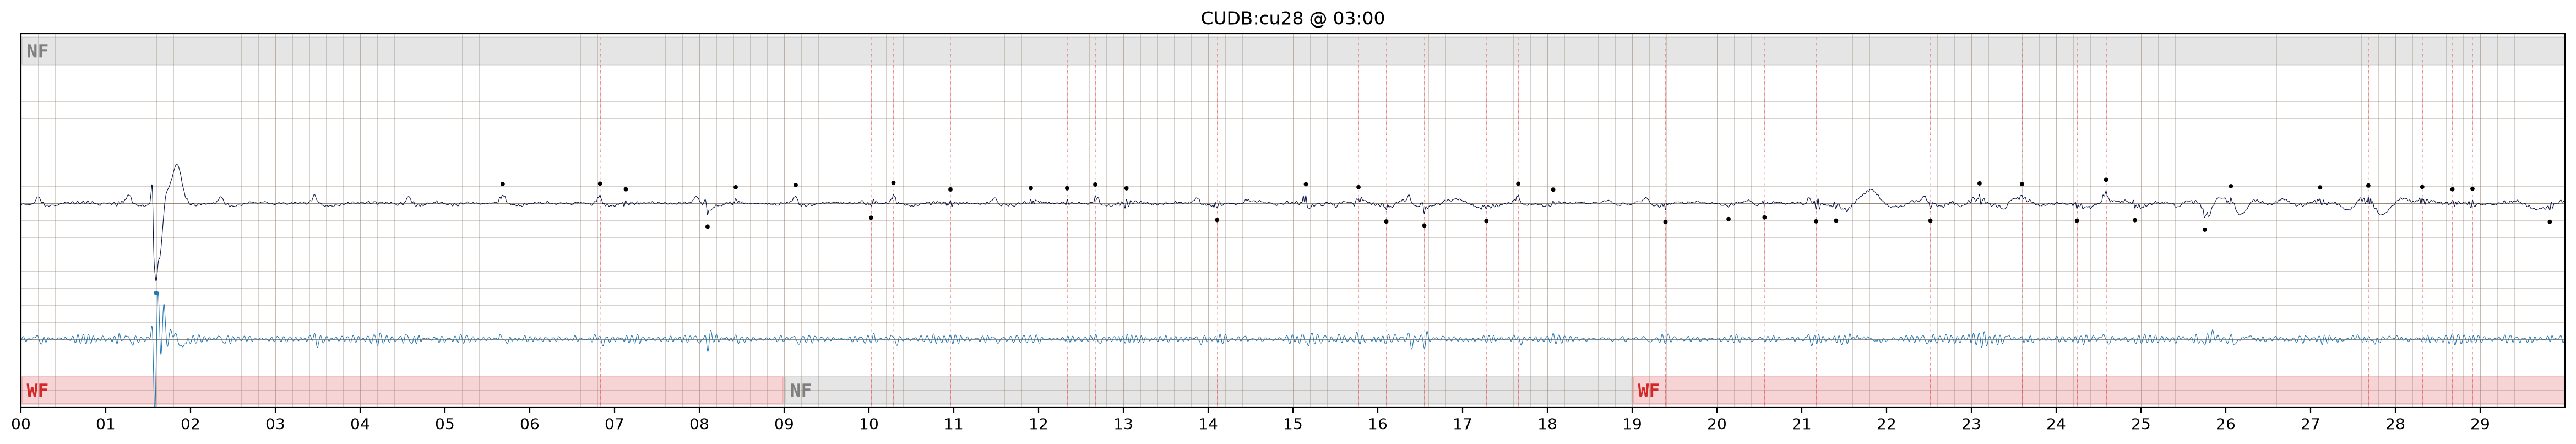

## CUDB cu28
---

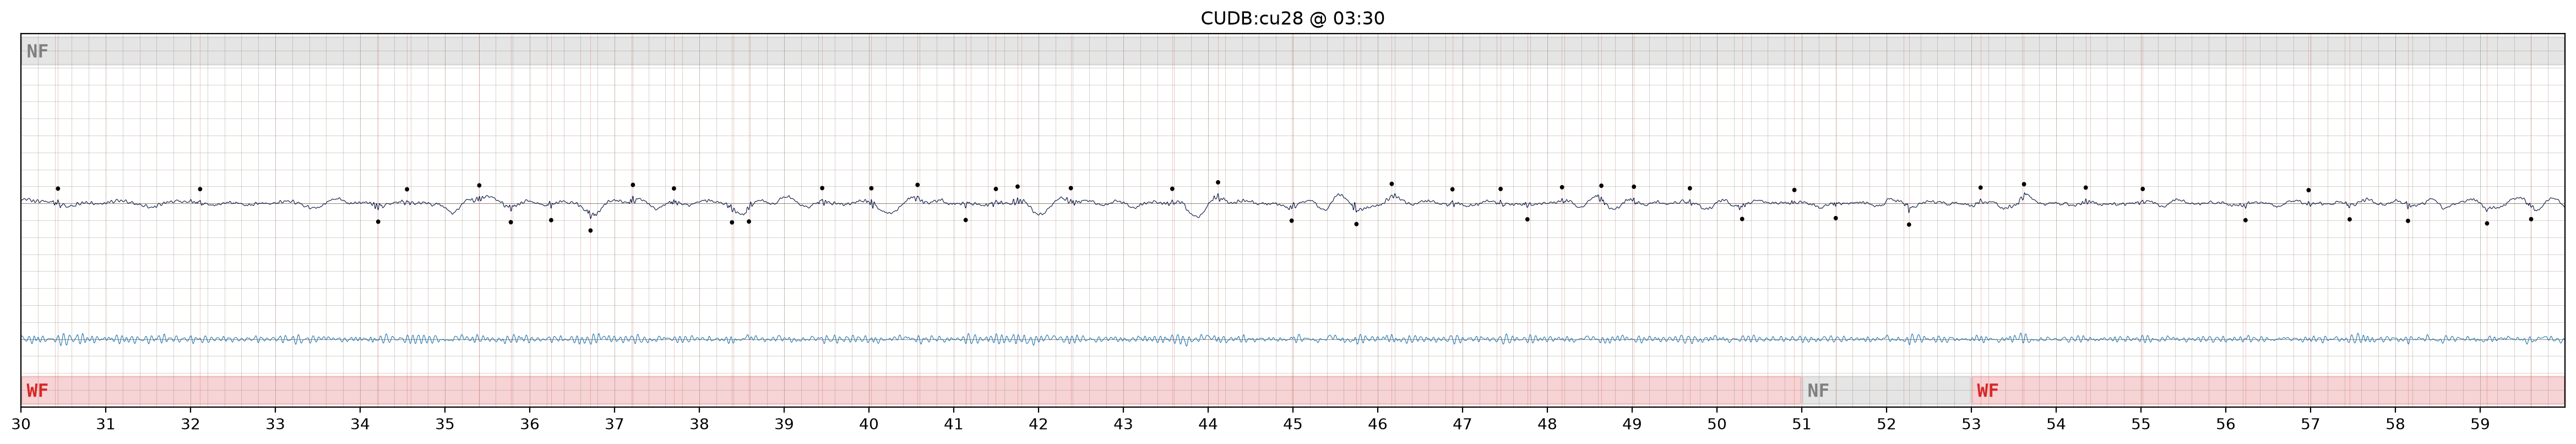

## CUDB cu28
---

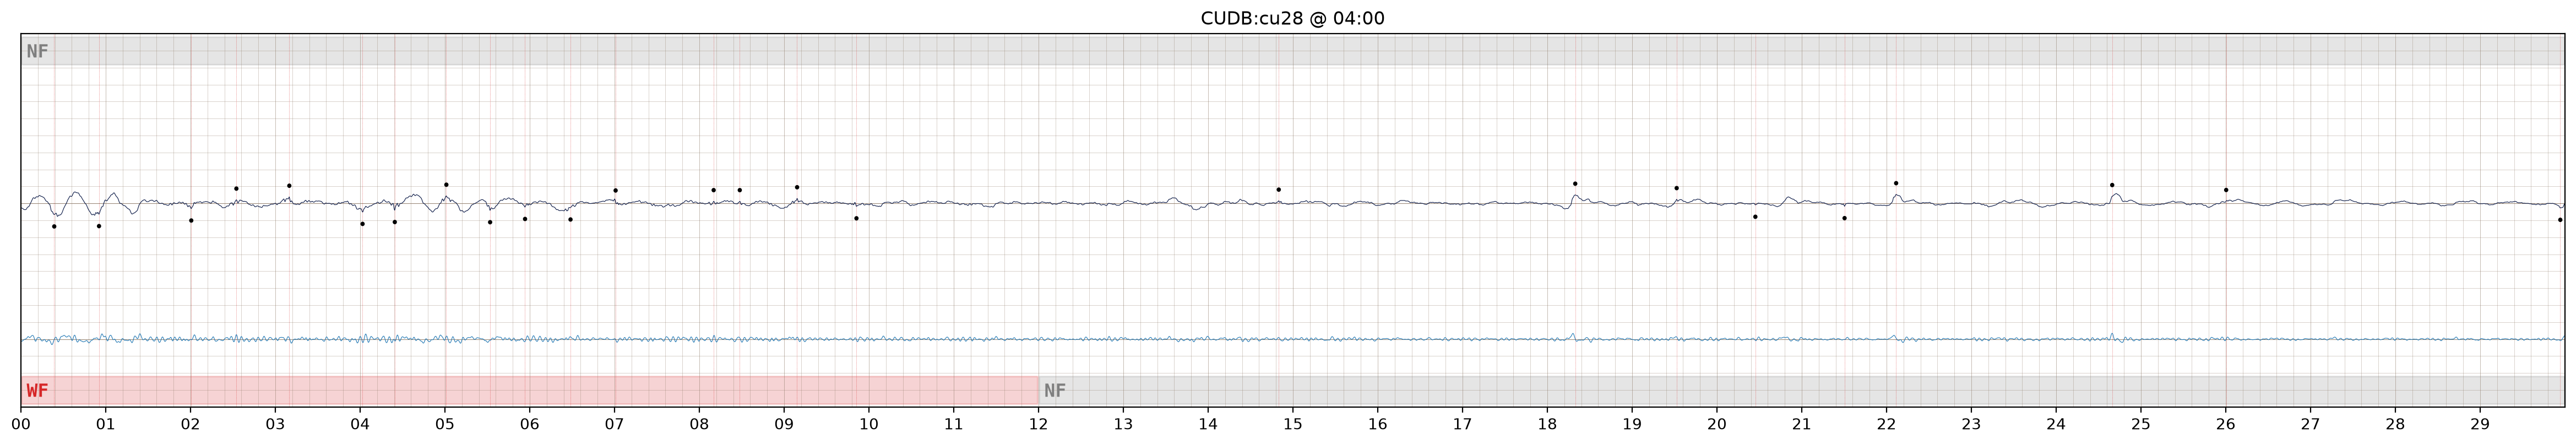

## CUDB cu28
---

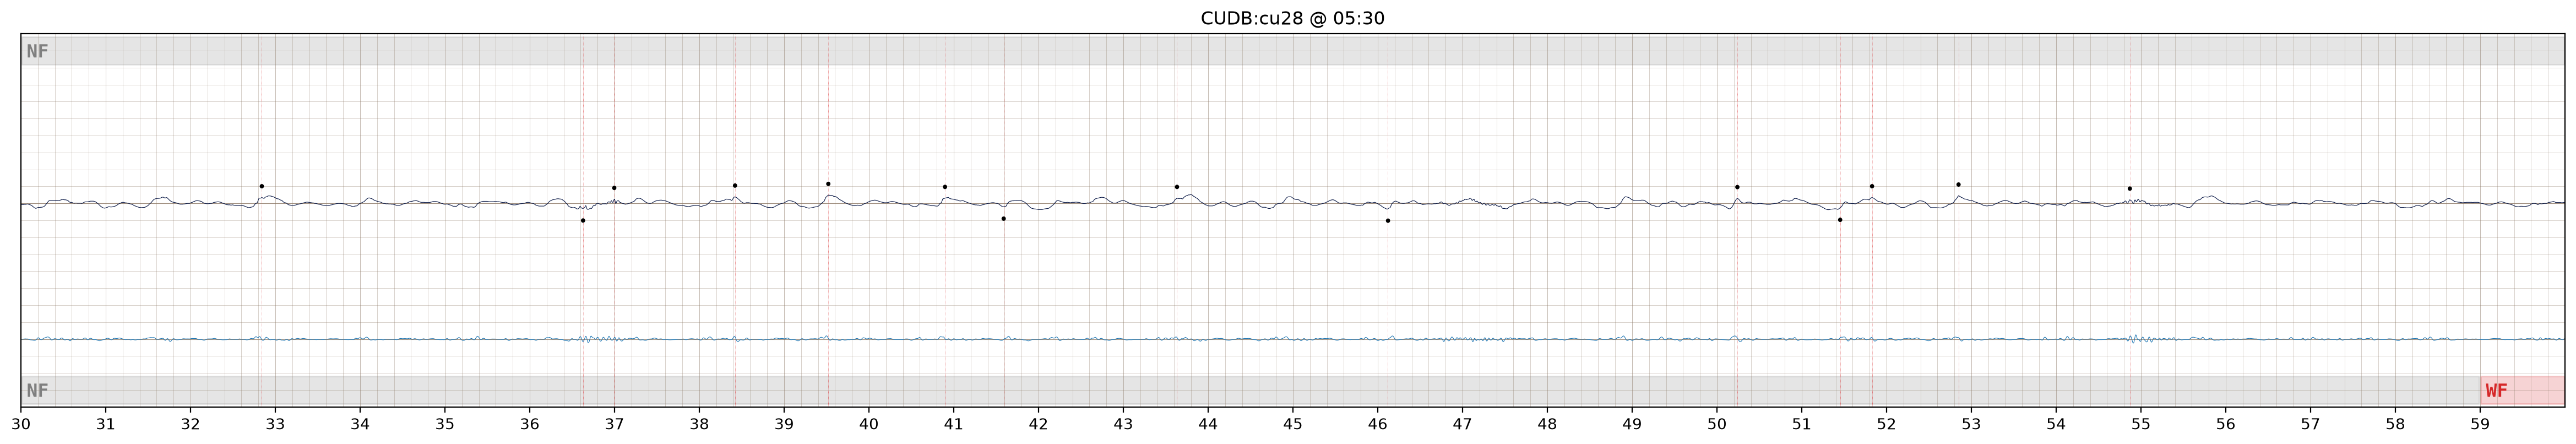

## CUDB cu28
---

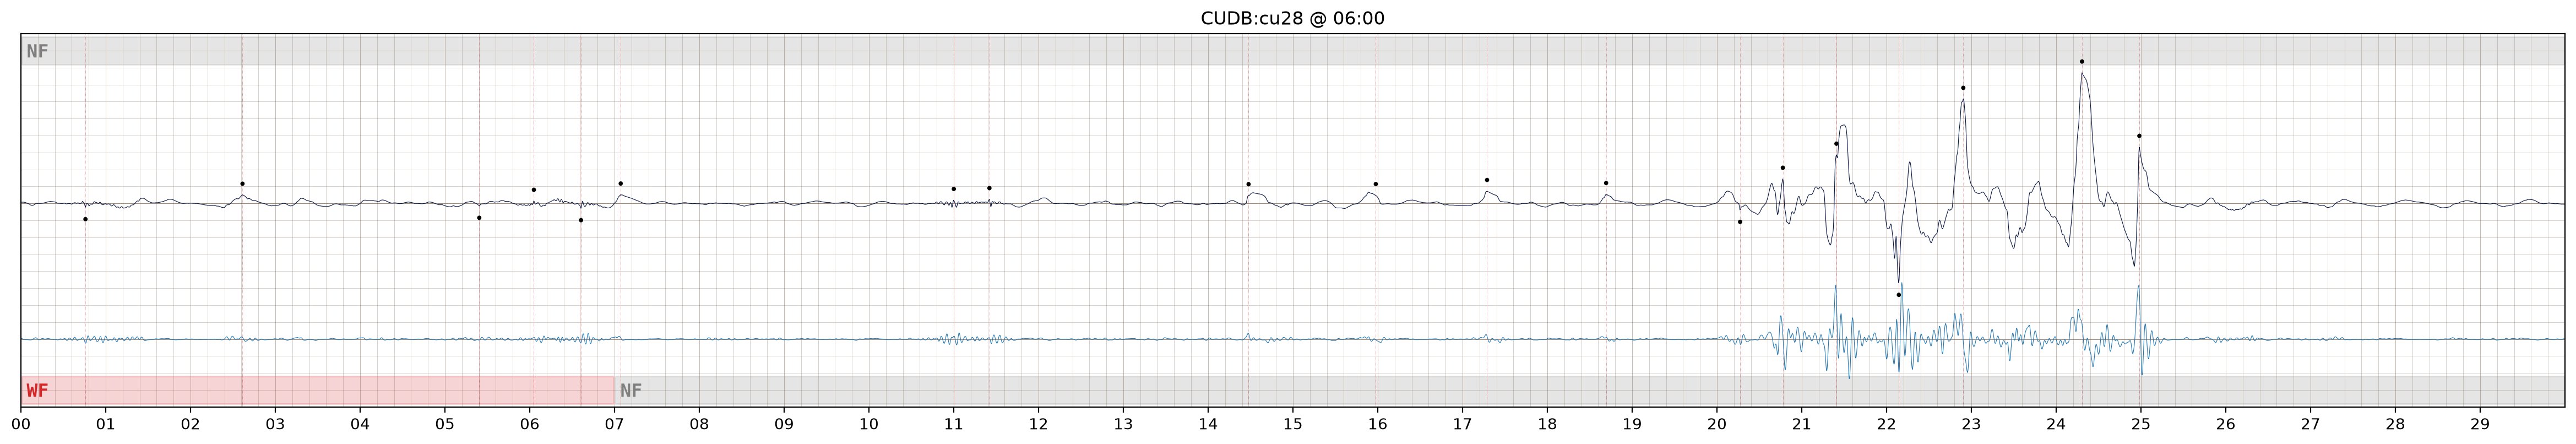

## CUDB cu28
---

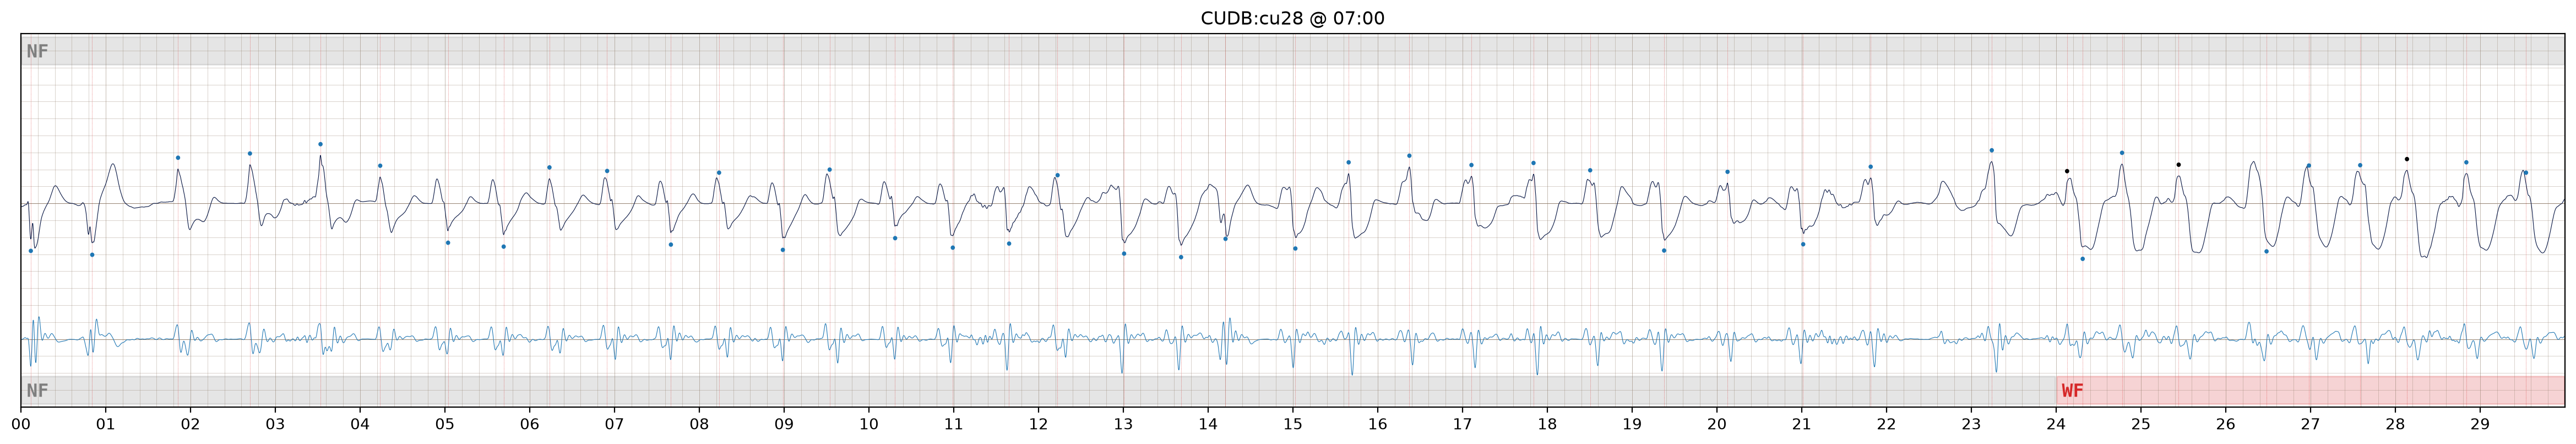

## CUDB cu28
---

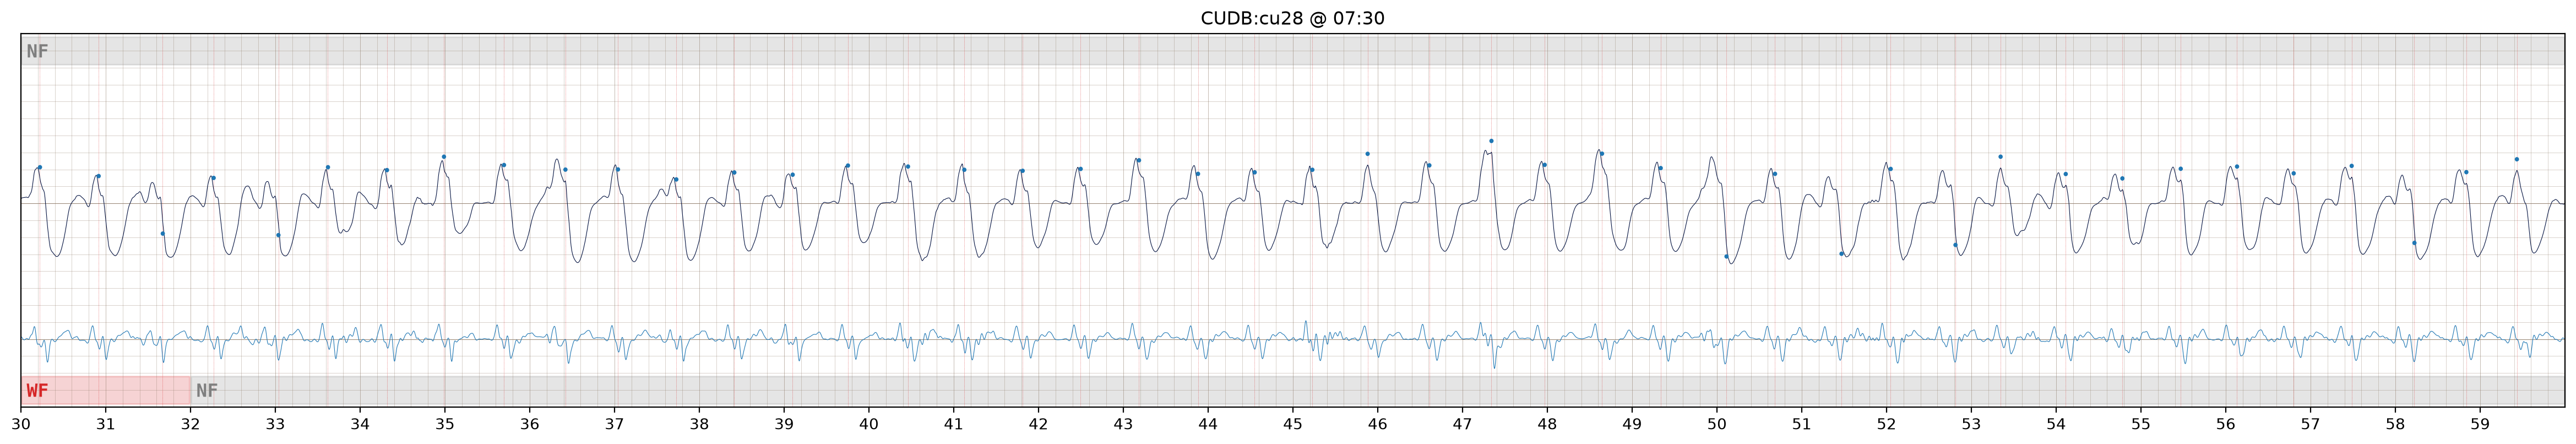

## CUDB cu28
---

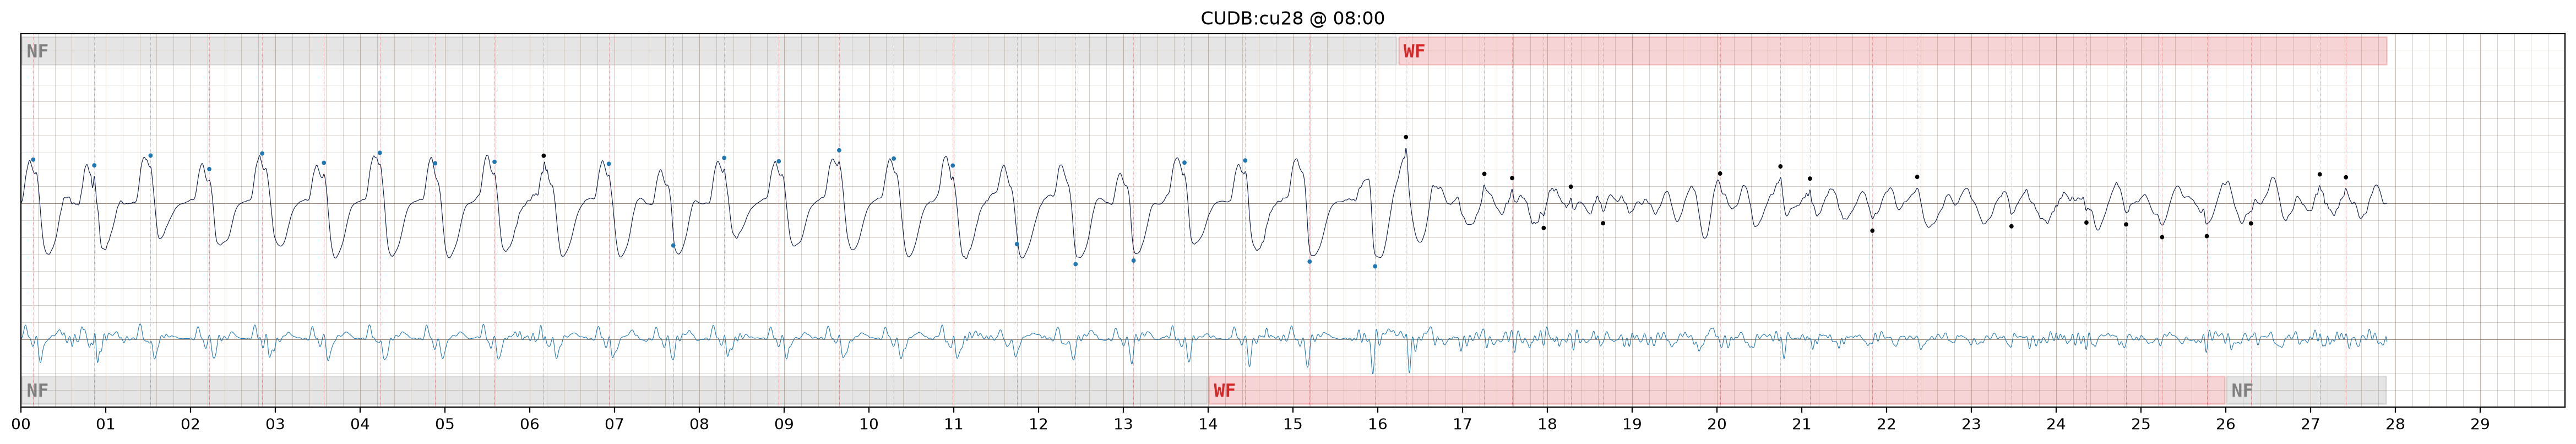

In [19]:
PlotDatabase("cudb", ["cu28", "#cu20", "#cu30", "#cu27"])

In [20]:
Stop()

# Decision tree on the counts c1, c2, c3
#
# A shallow tree just learns count thresholds (what the cascade does by hand), and
# its rules are readable. Evaluated two ways: in-sample (comparable to the manual
# thresholds, which were also tuned in-sample) and grouped cross-validation with
# GroupKFold by record, so windows from one record never leak between folds. The
# gap between the two is the per-record drift.

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import GroupKFold, cross_val_predict

TREE_DBS = ["mitdb", "ahadb", "cudb", "vfdb"]   # edb has no shockable windows

frames = []
for db in TREE_DBS:
    _, _, df8 = LoadDatabase(db)
    frames.append(df8)
pass #for
D = pd.concat(frames, ignore_index=True)

span = FS * 8
X = D[["c1", "c2", "c3"]].to_numpy(float)
y = (D["vfb"].to_numpy() >= FRAC * span).astype(int)
groups = (D["db"] + "/" + D["rid"].astype(str)).to_numpy()   # one group per record

def tree_report(y_true, y_pred, mask, name) -> dict:
    yy, pp = y_true[mask], y_pred[mask]
    tp = int(((pp == 1) & (yy == 1)).sum()); fp = int(((pp == 1) & (yy == 0)).sum())
    fn = int(((pp == 0) & (yy == 1)).sum()); tn = int(((pp == 0) & (yy == 0)).sum())
    return dict(set=name, shock=int(yy.sum()), TP=tp, FN=fn, FP=fp, TN=tn,
                SPC=round(100 * tn / (tn + fp), 2) if tn + fp else float("nan"),
                SEN=round(100 * tp / (tp + fn), 2) if tp + fn else float("nan"),
                PPV=round(100 * tp / (tp + fp), 2) if tp + fp else float("nan"),
                F1 =round(100 * 2 * tp / (2 * tp + fp + fn), 2) if 2 * tp + fp + fn else float("nan"))
pass #def

clf = DecisionTreeClassifier(max_depth=4, random_state=0)
insample = clf.fit(X, y).predict(X)
crossval = cross_val_predict(clf, X, y, groups=groups, cv=GroupKFold(5))

for tag, pred in [("in-sample", insample), ("grouped-CV", crossval)]:
    rows = [tree_report(y, pred, (D["db"] == db).to_numpy(), db) for db in TREE_DBS]
    rows.append(tree_report(y, pred, np.ones(len(y), bool), "POOLED"))
    display(Markdown(f"### Decision tree (depth 4) - {tag}"))
    display(pd.DataFrame(rows))
pass #for

# the learned thresholds
print(export_text(clf.fit(X, y), feature_names=["c1", "c2", "c3"], max_depth=3))

>>> STOP
